In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc, rcParams
from matplotlib.ticker import AutoMinorLocator
import pandas as pd
import tkinter as tk
from tkinter import filedialog
import os

## Module for plotting "chromatograms" generated from the SEC_SAXS_main file
By default, tkinter file browser does not work on jupyterhub. So the method here is to navigate with the file tab on the left to the files to plot.
Right click, and copy path.

In [13]:
file_paths = ['data/visitors/cosaxs/20250420/2025090908/process_sec-saxs/chromatogram_output/62750_chromatogram_qmin0.003_qmax0.01.dat',
              'data/visitors/cosaxs/20250420/2025090908/process_sec-saxs/chromatogram_output/62750_chromatogram_qmin0.01_qmax0.08.dat',
             ]

In [14]:
df_chr = {}
for file_path in file_paths:
    df_chr[file_path] = pd.read_csv(f'/{file_path}', sep= r'\s+', header=None, skiprows=1, engine='python')

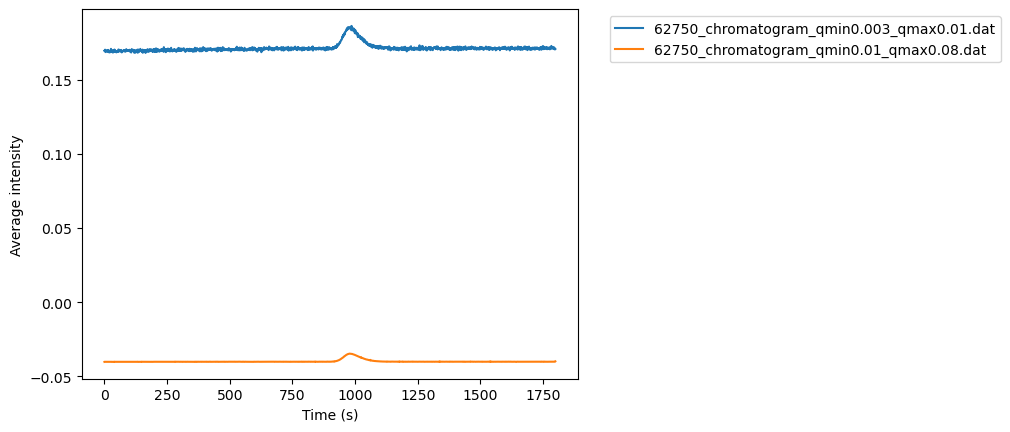

In [15]:
plt.close('all')
plt.figure()
scale = [6.5,0.9,110]
bkg = [0,0.05,0.05]
for idx, (file_path, data) in enumerate(df_chr.items()):
    time = data.iloc[:,0]
    intensity = data.iloc[:,1]
    plt.plot(time, intensity*scale[idx]-bkg[idx], label=file_path.split('/')[-1])  # Plot with filename as label

plt.xlabel('Time (s)')
plt.ylabel('Average intensity')
plt.yscale('linear')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.show()

## Module for plotting I vs. q generated from the SEC_SAXS file
By default, tkinter file browser does not work on jupyterhub. So the method here is to navigate with the file tab on the left to the files to plot.
Right click, and copy path.

In [16]:
file_paths = ['data/visitors/cosaxs/20250420/2025090908/process_sec-saxs/saxs_output/62750_sample_1_subtracted_1_0960_1002.dat',
              'data/visitors/cosaxs/20250420/2025090908/process_sec-saxs/saxs_output/62750_buffer_1_0200_0400.dat',
              'data/visitors/cosaxs/20250420/2025090908/process_sec-saxs/saxs_output/62750_sample_1_0960_1002.dat',
             ]

In [17]:
df = {}
for file_path in file_paths:
    df[file_path] = pd.read_csv(f'/{file_path}', sep= r'\s+', header=None, skiprows=1, engine='python')

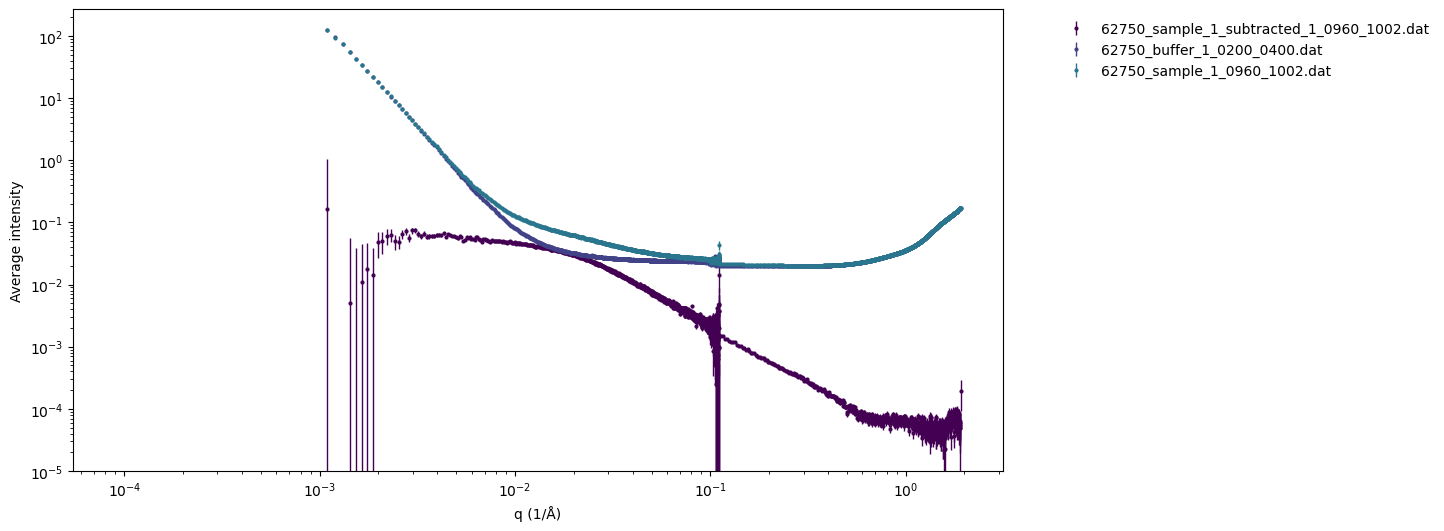

In [18]:
plt.figure(figsize=(12,6))
colormap = plt.get_cmap('viridis')
count = 0
for file_path, data in df.items():
    q = data.iloc[:,0]
    intensity = data.iloc[:,1]
    err = data.iloc[:,2] if data.shape[1] > 2 else None
    plt.errorbar(q, intensity, yerr=err, fmt='o', markersize = 2, elinewidth= 1,label=file_path.split('/')[-1], color = colormap((count) % colormap.N))  # Plot with filename as label
    count += 50

plt.xlabel('q (1/Å)')
plt.ylabel('Average intensity')
plt.yscale('log')
plt.xscale('log')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, frameon=False)
plt.show()